# 02 — Portugal core models

The full estimator stack for one country, in the order the research design
intends: reliability flags first, then coefficients.

Reading the coefficients before the flags is the mistake this ordering exists to
prevent. A flexible model fitted to thirty annual observations will always return
a number; the flags say whether that number carries information.

In [1]:
from pathlib import Path

import pandas as pd

from wage_transmission.config import load_models_config
from wage_transmission.pipeline import analyse_country

PROCESSED = Path("../data/processed/panel.csv")
REFERENCE = Path("../data/reference/portugal_oecd_1995_2025.csv")

source = PROCESSED if PROCESSED.exists() else REFERENCE
panel = pd.read_csv(source)
portugal = panel.loc[panel["country"] == "PRT"].copy()
config = load_models_config(Path("../config/models.yml"))
print(f"Source in use: {source}")
print(f"Observations: {len(portugal)}")
print("Bootstrap inference enabled:", config.inference.enabled)

Source in use: ..\data\reference\portugal_oecd_1995_2025.csv
Observations: 31
Bootstrap inference enabled: True


In [2]:
# The pipeline runs every estimator and serialises the results. Bootstrap
# replications dominate the runtime; set inference.enabled to false in
# config/models.yml for a fast exploratory pass.
results = analyse_country(
    portugal,
    Path("../results/notebook_portugal"),
    model_config=config,
)
results["reliability"]

C:\Users\diogo\work_code\gdp-wage-transmission\src\wage_transmission\diagnostics\stationarity.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, _ = kpss(array, regression=regression, nlags="auto")


ReliabilityAssessment(cointegration_supported_5pct=False, ecm_long_run_interpretation='unsupported_without_cointegration', asymmetry_min_shock_count=5, asymmetry_interpretation='underpowered_shock_balance', state_space_latest_z_score=0.46297849914280703, state_space_latest_distinguishable_from_zero_95pct=False, state_space_interpretation='latest_slope_imprecise', structural_break_smallest_segment=8, structural_break_interpretation='small_regime_segments', local_projection_min_nobs=25, local_projection_supported_horizons=(0, 1, 2, 3), local_projection_exploratory_horizons=(4, 5, 6, 7, 8), local_projection_interpretation='long_horizons_exploratory', warnings=('Engle-Granger does not support cointegration at 5%; do not interpret the ECM long-run elasticity as established.', 'Too few productivity changes of the rarer sign for a stable positive-versus-negative response comparison.', 'The latest time-varying elasticity is not distinguishable from zero at the configured normal-approximation t

## Sample adequacy

The audit reports what the sample can support before any model is interpreted.

In [3]:
results["empirical_audit"]

EmpiricalAudit(start_year=1995, end_year=2025, n_levels=31, n_growth_observations=30, annualized_wage_growth=0.009133886377733491, annualized_driver_growth=0.009945672447416953, growth_correlation=0.08680311797902172, positive_driver_changes=23, negative_driver_changes=5, zero_driver_changes=2)

## Long run: cointegration and the ECM

The ECM's long-run coefficient is a **conditional** quantity. If the
Engle–Granger diagnostic does not support cointegration, the long-run elasticity
is not evidence of a long-run relationship, and the flag below says so.

In [4]:
cointegration = results["diagnostics"]["cointegration"]
print("Engle-Granger p-value:", round(cointegration["p_value"], 4))
print("Supported at 5%:", results["diagnostics"]["cointegration_supported_5pct"])
print()
results["ecm"]

Engle-Granger p-value: 0.4073
Supported at 5%: False



ECMResult(summary=ModelSummary(model='ecm', nobs=30, coefficients=(RegressionCoefficient(name='const', estimate=0.006863870561356938, std_error=0.005575425973029919, p_value=0.21828790395999198), RegressionCoefficient(name='ect_l1', estimate=-0.016311322667789716, std_error=0.08838410127796598, p_value=0.8535816799722173), RegressionCoefficient(name='dprod_l0', estimate=0.21898853337501406, std_error=0.4728589593529519, p_value=0.6432812469129189)), diagnostics={'r_squared': 0.008521570787760502, 'aic': -139.7204559368016, 'bic': -135.51686379181515, 'long_run_r_squared': 0.3129939392363902, 'hac_lags': 2}), long_run_intercept=9.143118843317119, long_run_elasticity=0.37499427828895016, adjustment_speed=-0.016311322667789716, wage_growth_lags=0, productivity_growth_lags=0)

## Primary estimand: cumulative distributed-lag transmission

This is the pre-specified primary quantity. Everything below it is supporting
evidence, reliability-gated.

In [5]:
results["distributed_lag"]

DistributedLagResult(summary=ModelSummary(model='distributed_lag', nobs=28, coefficients=(RegressionCoefficient(name='const', estimate=0.011481451664150131, std_error=0.00738675128976791, p_value=0.1201056393382669), RegressionCoefficient(name='prod_l0', estimate=-0.0034339737173758045, std_error=0.5604548031056763, p_value=0.995111296303022), RegressionCoefficient(name='prod_l1', estimate=-0.6353856521006858, std_error=0.2855910939070924, p_value=0.026094059187514555), RegressionCoefficient(name='prod_l2', estimate=0.03149406216419559, std_error=0.4140701739950513, p_value=0.9393715847681872), RegressionCoefficient(name='wage_l1', estimate=0.27167232853537376, std_error=0.14027260751667778, p_value=0.05277647210069904)), diagnostics={'r_squared': 0.14238225459480536, 'aic': -130.4313419889234, 'bic': -123.77031943804738, 'x_lags': 2, 'y_lags': 1, 'hac_lags': 2}), cumulative_transmission=-0.607325563653866, cumulative_std_error=0.7075218721527285, cumulative_p_value=0.39068037457477744

## Breaks: two different questions

The BIC segmentation asks *how many regimes fit best*. It always returns a
partition, so it cannot tell you whether a break exists at all.

The sup-F test asks *is there evidence of a break*, with a wild-bootstrap p-value
computed by re-running the entire date search on each replication — so the
p-value already accounts for having looked at every candidate date. The two are
reported separately because they answer different questions.

In [6]:
results["structural_breaks"]

StructuralBreakResult(break_years=(2004, 2013), segments=(BreakSegment(start_year=1996, end_year=2003, intercept=-0.013283818841575073, elasticity=2.215052121213225, rss=0.00023500431260892944, nobs=8), BreakSegment(start_year=2004, end_year=2012, intercept=0.008222289154869432, elasticity=-1.0327630540571926, rss=0.0035287895310221343, nobs=9), BreakSegment(start_year=2013, end_year=2025, intercept=0.009068021453148145, elasticity=1.3760280977328956, rss=0.002578744676043894, nobs=13)), bic=-233.44302295725936, n_breaks=2)

In [7]:
inference = results["break_inference"]
if inference is None:
    print("Bootstrap inference is disabled in config/models.yml.")
else:
    print(f"Break year          : {inference.break_year}")
    print(f"Bootstrap interval  : {inference.break_year_lower}-{inference.break_year_upper}")
    print(f"sup-F               : {inference.sup_f:.3f}")
    print(f"p-value             : {inference.p_value:.4f}")
    print(f"Elasticity before   : {inference.pre_break_elasticity:.3f}")
    print(f"Elasticity after    : {inference.post_break_elasticity:.3f}")
    print(f"Verdict             : {inference.interpretation}")

Break year          : 2018
Bootstrap interval  : 2009-2019
sup-F               : 4.324
p-value             : 0.1685
Elasticity before   : 0.165
Elasticity after    : 0.916
Verdict             : no_break_detected


## Time-varying elasticity

The filtered standard errors condition on the estimated variance parameters and
ignore the uncertainty in estimating them — which matters, because the state
variance is exactly what governs how much the elasticity is allowed to move. The
block-bootstrap band re-estimates the whole model per replication.

The band is pointwise. It does not license a claim about the path as a whole,
such as a decline between two particular years.

In [8]:
band = results["time_varying_elasticity_bands"]
state = results["state_space"]
if band is None:
    print("Bootstrap bands are disabled in config/models.yml.")
else:
    comparison = pd.DataFrame(
        {
            "year": band.year,
            "elasticity": band.estimate,
            "filtered_lower": state.elasticity - 1.96 * state.elasticity_std_error,
            "filtered_upper": state.elasticity + 1.96 * state.elasticity_std_error,
            "bootstrap_lower": band.lower_95,
            "bootstrap_upper": band.upper_95,
        }
    )
    comparison["filtered_width"] = comparison["filtered_upper"] - comparison["filtered_lower"]
    comparison["bootstrap_width"] = comparison["bootstrap_upper"] - comparison["bootstrap_lower"]
    display(comparison.tail(8).round(3))
    print(
        "Median width, filtered vs bootstrap: "
        f"{comparison['filtered_width'].median():.3f} vs "
        f"{comparison['bootstrap_width'].median():.3f}"
    )

,year,elasticity,filtered_lower,filtered_upper,bootstrap_lower,bootstrap_upper,filtered_width,bootstrap_width
22,2018,0.082,-0.850,1.014,-0.842,1.225,1.864,2.067
23,2019,0.184,-0.741,1.108,-0.810,1.217,1.849,2.027
24,2020,0.141,-0.762,1.044,-0.823,1.216,1.807,2.039
25,2021,0.144,-0.760,1.047,-0.826,1.194,1.807,2.020
26,2022,0.158,-0.744,1.060,-0.810,1.194,1.804,2.004
27,2023,0.038,-0.854,0.931,-0.802,1.184,1.785,1.986
28,2024,0.238,-0.609,1.085,-0.779,1.166,1.695,1.945
29,2025,0.196,-0.635,1.028,-0.772,1.148,1.663,1.920


Median width, filtered vs bootstrap: 2.703 vs 2.424


## Local projections

Local-projection windows overlap, so the effective sample at long horizons is far
smaller than the nominal one and the HAC errors are optimistic there. Comparing
the two interval widths shows how much.

These are dynamic associations. Calling them impulse responses would require an
identified productivity shock, which this design does not claim.

In [9]:
bands = results["local_projection_bands"]
points = results["local_projections"]
if not bands:
    print("Bootstrap bands are disabled in config/models.yml.")
else:
    frame = pd.DataFrame(
        {
            "horizon": [p.horizon for p in points],
            "estimate": [p.estimate for p in points],
            "hac_width": [(p.upper_95 - p.lower_95) for p in points],
            "bootstrap_width": [(b.upper_95 - b.lower_95) for b in bands],
            "nobs": [p.nobs for p in points],
        }
    )
    frame["bootstrap_wider_by"] = frame["bootstrap_width"] / frame["hac_width"]
    display(frame.round(3))

,horizon,estimate,hac_width,bootstrap_width,nobs,bootstrap_wider_by
0,0,-0.043,1.966,2.315,28,1.178
1,1,-0.831,3.490,3.504,27,1.004
2,2,-1.556,4.440,4.417,26,0.995
3,3,-1.163,4.177,4.896,25,1.172
4,4,-1.962,3.935,5.514,24,1.401
5,5,-2.140,4.033,6.284,23,1.558
6,6,-2.237,2.845,6.771,22,2.380
7,7,-3.500,2.367,7.612,21,3.216
8,8,-3.314,2.574,7.916,20,3.075


## Figures

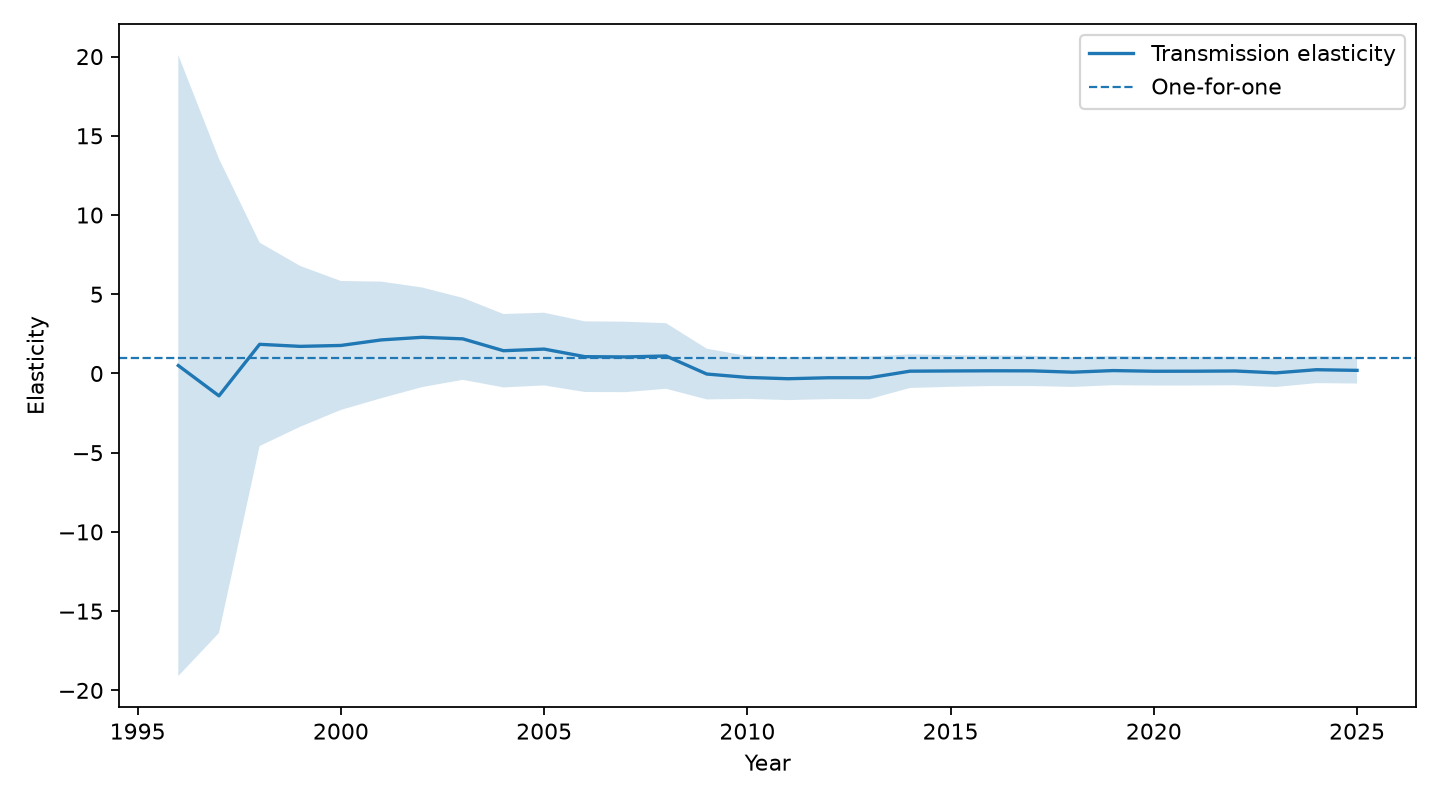

In [10]:
from IPython.display import Image

Image(filename="../results/notebook_portugal/time_varying_elasticity.png")

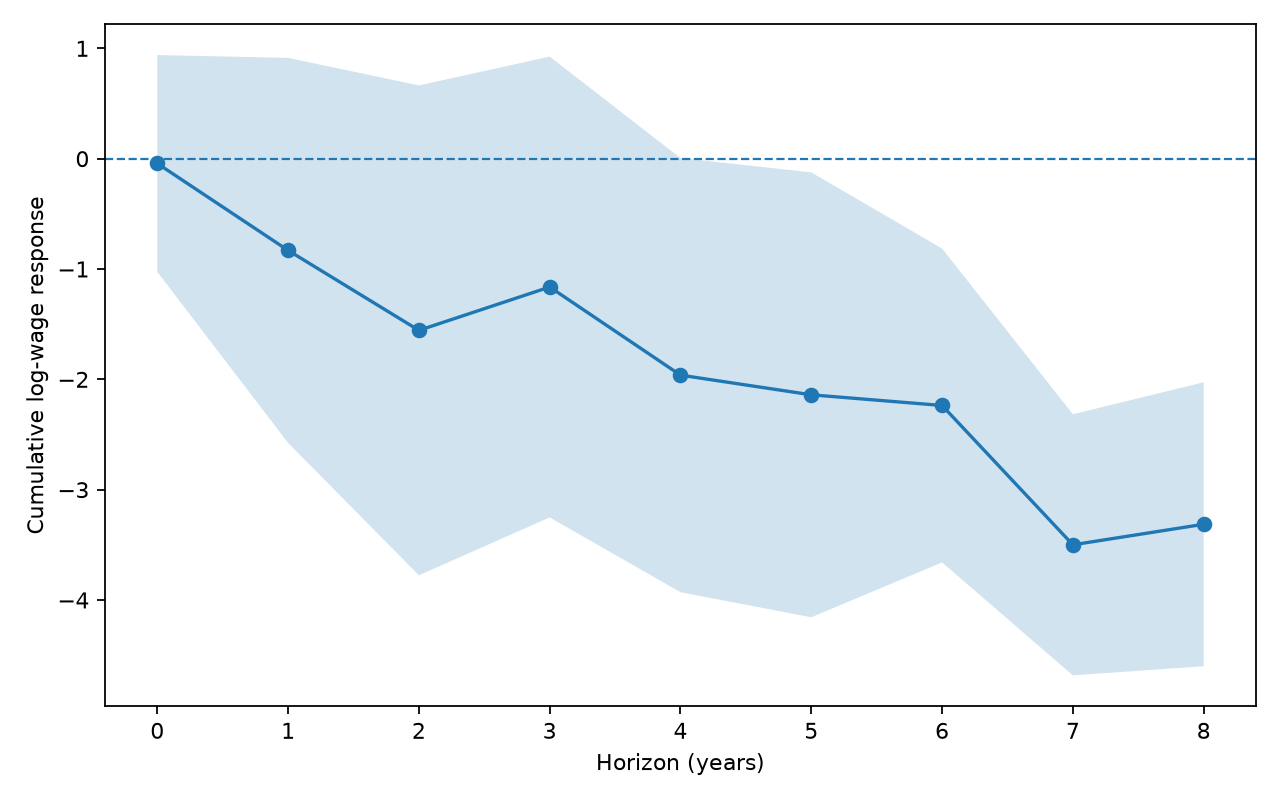

In [11]:
Image(filename="../results/notebook_portugal/local_projections.png")

## What this notebook does not establish

None of the above is causal. The transmission elasticity is an association
between two series that are jointly determined; a break locates a date without
explaining it; and the reliability flags mark where the sample is too short to
support the flexible specifications at all.